In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
## define state
class BMIState(TypedDict):
    
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [3]:
def calculate_BMI(state: BMIState)-> BMIState:
    
    weight = state['weight_kg']
    height = state['height_m']
    
    bmi = weight / (height**2)
    
    state['bmi'] = round(bmi, 2)
    
    return state

In [11]:
def label_BMI(state: BMIState)-> BMIState:
    
    bmi = state['bmi']
    
    if bmi < 18.5:
        state['category'] = "Underweight"
    elif 18.5 <= bmi < 25:
        state['category'] = "Normal"
    elif 25 <= bmi < 30:
        state['category'] = "Overweight"
    else:
        state['category'] = "Obese"
        
    return state

In [12]:
## define graph
graph = StateGraph(BMIState)

# add nodees
graph.add_node('calculate_BMI', calculate_BMI)
graph.add_node('label_BMI', label_BMI)

# add edges
graph.add_edge(START, 'calculate_BMI')
graph.add_edge('calculate_BMI', 'label_BMI')
graph.add_edge('label_BMI', END)

# compile the grraph
workflow = graph.compile()


In [13]:
# execute the graph

initial_state = {'weight_kg':80, 'height_m':1.73}
final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


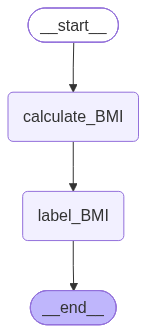

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())